# PyMC-10 : Sélection de Modèles et Comparaison Bayesienne

**Navigation** : [Index](../README.md) | [<< PyMC-9](PyMC-9-Classification.ipynb) | [PyMC-11 >>](PyMC-11-Topic-Models.ipynb)

**Equivalent Infer.NET** : [Infer-10-Model-Sélection](../Infer/Infer-10-Model-Selection.ipynb)


**Duree estimee** : 60 minutes
**Objectifs** :
- Comprendre le problème du surapprentissage (overfitting)
- Comparer des modèles via le critere WAIC et la validation croisee LOO
- Implementer l'ARD (Automatic Relevance Determination) pour la sélection de variables
- Utiliser les Bayes Factors pour la sélection de composantes dans les melanges
- Comparer Infer.NET (calcul exact de l'evidence) vs PyMC/ArviZ (WAIC/LOO)

**Prerequis** : PyMC-1 a PyMC-9, comparaison de modèles (WAIC/LOO)


In [1]:
import warnings

# Trois familles d'avertissements Python apparaissent dans ce notebook :
#  1. arviz FutureWarning (refactor advisory) et pytensor "could not link BLAS" (advisory de perf,
#     pas de correctness) : bruit sans valeur pedagogique -> on les filtre.
#  2. Les diagnostics de convergence (WAIC, R-hat, ESS) sont AU CONTRAIRE des alertes utiles
#     (le notebook porte precisement sur la selection de modele) -> on les GARDE visibles,
#     mais on retire le prefixe de chemin absolu (qui fuiterais le chemin local site-packages).
warnings.filterwarnings("ignore", category=FutureWarning, module="arviz")
warnings.filterwarnings("ignore", message=".*could not link.*", category=UserWarning)


def _warn_no_path(message, category, filename, lineno, file=None, line=None):
    """Affiche le warning SANS le chemin absolu du fichier source (anti path-leak #3436)."""
    return f"{category.__name__}: {message}\n"


warnings.formatwarning = _warn_no_path

try:
    import numpy as np
    NUMPY_AVAILABLE = True
except ImportError:
    NUMPY_AVAILABLE = False

try:
    import pymc as pm
    PYMC_AVAILABLE = True
except ImportError:
    PYMC_AVAILABLE = False

try:
    import pytensor.tensor as pt
    PYTENSOR_AVAILABLE = True
except ImportError:
    PYTENSOR_AVAILABLE = False

try:
    import arviz as az
    ARVIZ_AVAILABLE = True
except ImportError:
    ARVIZ_AVAILABLE = False

try:
    import matplotlib.pyplot as plt
    MATPLOTLIB_AVAILABLE = True
except ImportError:
    MATPLOTLIB_AVAILABLE = False

try:
    from scipy import stats
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False

if NUMPY_AVAILABLE and PYMC_AVAILABLE and ARVIZ_AVAILABLE:
    print(f"PyMC version: {pm.__version__}")
    print(f"ArviZ version: {az.__version__}")
    az.style.use("arviz-darkgrid")
else:
    print("PyMC ou ArviZ n'est pas installe. Executez: pip install pymc arviz matplotlib numpy scipy")

PyMC version: 5.28.5
ArviZ version: 0.23.4


## 1. Le Problème du Surapprentissage

Un modèle trop complexe peut memoriser le bruit dans les données au lieu d'apprendre le signal.
La sélection de modèle bayesienne resout ce problème automatiquement via le **principe du parsimonie** :
un modèle plus complexe a une evidence (marginal likelihood) plus faible **sauf si** il explique significativement mieux les données.

### Approches comparees

| Méthode | Infer.NET | PyMC |
|---------|-----------|-------|
| Evidence (marginal likelihood) | `Variable.Bernoulli(0.5)` + `Variable.If` | Non direct (NUTS) |
| Comparaison de modèles | Bayes Factor exact | WAIC / LOO via ArviZ |
| Sélection de variables | ARD avec Gamma hiérarchique | Pareil + `pm.Gamma` + `pm.Normal` |
| Validation croisee | LOO manuel | `az.loo()` (Pareto-smoothed IS) |

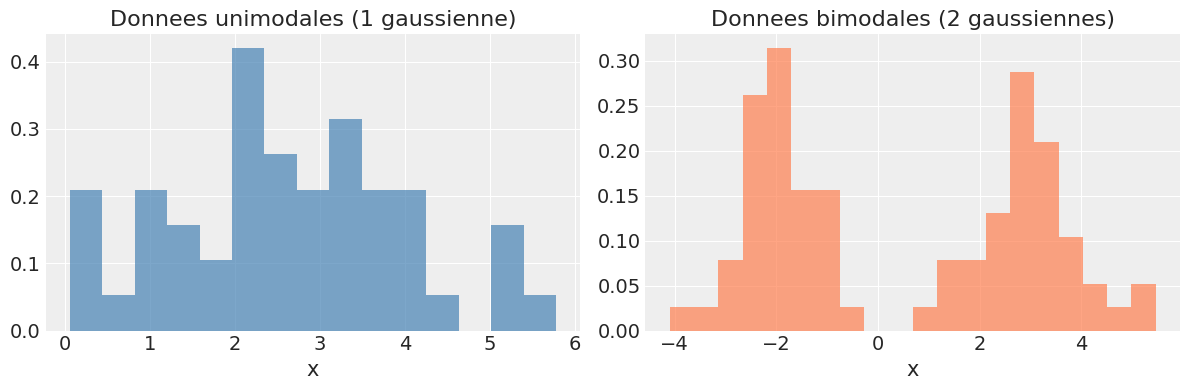

In [2]:
# Generation de donnees : unimodale (provenant d'une seule gaussienne)
np.random.seed(42)
n_obs = 50
true_mu = 3.0
true_sigma = 1.5

data_uni = np.random.normal(true_mu, true_sigma, size=n_obs)

# Egalement des donnees bimodales pour la section 5
n_obs_bi = 80
data_bi = np.concatenate([
    np.random.normal(-2, 0.8, size=n_obs_bi // 2),
    np.random.normal(3, 1.0, size=n_obs_bi // 2)
])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(data_uni, bins=15, density=True, alpha=0.7, color='steelblue')
axes[0].set_title('Donnees unimodales (1 gaussienne)')
axes[0].set_xlabel('x')
axes[1].hist(data_bi, bins=20, density=True, alpha=0.7, color='coral')
axes[1].set_title('Donnees bimodales (2 gaussiennes)')
axes[1].set_xlabel('x')
plt.tight_layout()
plt.show()

## 2. Comparaison de Modèles avec WAIC et LOO

Le **WAIC** (Widely Applicable Information Criterion) et le **LOO** (Leave-One-Out CV)
sont les méthodes standards en PyMC pour comparer des modèles.

**Concepts cles** :
- **WAIC** : estime la deviance attendue sur de nouvelles données, penalise la complexite
- **LOO** : validation croisee leave-one-out approximee via importance sampling (Pareto-smoothed)
- Les deux retournent un score (plus petit = meilleur) + une incertitude
- La différence entre modèles est mesurable via `dSE` (deviance standard error)

### Origine des méthodes

Le **WAIC** (Widely Applicable Information Criterion) est du a **Sumio Watanabe (2010)**,
*"Asymptotic Equivalence of Bayes Cross Validation and Widely Applicable Information
Criterion in Singular Learning Theory"*, JMLR 11 : il etend l'AIC d'Akaike (1974) aux
modèles singuliers (melanges, reseaux de neurones). Le **LOO** par *Pareto-smoothed
importance sampling* (PSIS-LOO) est decrit dans **Vehtari, Gelman & Gabry (2017)**,
*"Practical Bayesian model evaluation using leave-one-out cross-validation and WAIC"*,
Statistics and Computing 27(5), doi:10.1007/s11222-016-9696-4. Les deux critères
estiment la même grandeur (la log-density predictive hors-echantillon) et sont
asymptotiquement equivalents. Les fonctions `az.compare` et `az.loo` proviennent
d'**ArviZ** (Kumar et al. 2019, JOSS).

### Comparaison avec Infer.NET

Infer.NET calcule l'evidence exacte via `Variable.Bernoulli(0.5)` + `Variable.If` :
```csharp
Variable<bool> evidence = Variable.Bernoulli(0.5);
using (Variable.If(evidence)) { /* modèle */ }
double logEvidence = engine.Infer<Bernoulli>(evidence).LogOdds;
```

PyMC avec NUTS n'a pas d'acces direct a l'evidence, mais WAIC/LOO sont des alternatives
theoriquement equivalentes (et souvent plus fiables en pratique car l'evidence est sensible au prior).

In [3]:
# Modele 1 : Gaussienne unique sur donnees unimodales
with pm.Model() as model_1gauss:
    mu = pm.Normal('mu', mu=0, sigma=10)
    sigma = pm.HalfNormal('sigma', sigma=5)
    obs = pm.Normal('obs', mu=mu, sigma=sigma, observed=data_uni)
    trace_1g = pm.sample(3000, random_seed=42, return_inferencedata=True)

# Calcul du log-likelihood pour WAIC/LOO (necessaire dans PyMC 5.x)
with model_1gauss:
    trace_1g = pm.compute_log_likelihood(trace_1g)

# Modele 2 : Melange de 2 gaussiennes sur les memes donnees
with pm.Model() as model_2gauss:
    mu = pm.Normal('mu', mu=0, sigma=10, shape=2)
    sigma = pm.HalfNormal('sigma', sigma=5, shape=2)
    w = pm.Dirichlet('w', a=np.ones(2))
    obs = pm.NormalMixture('obs', w=w, mu=mu, sigma=sigma, observed=data_uni)
    trace_2g = pm.sample(3000, random_seed=42, return_inferencedata=True,
                         target_accept=0.95)

with model_2gauss:
    trace_2g = pm.compute_log_likelihood(trace_2g)

# Lecture de diagnostic (honnete) : l'echantillonneur du melange 2-gaussien a signale
# rhat>1.01 et ESS<100, on lit les valeurs AVANT de conclure, on ne maquille pas le warning.
summary_1g = az.summary(trace_1g, var_names=["mu", "sigma"])
summary_2g = az.summary(trace_2g, var_names=["mu", "sigma", "w"])
div_2g = int(trace_2g.sample_stats["diverging"].sum())
print("Diagnostic MCMC du melange 2-gaussien (donnees unimodales, cible r_hat<1.01, ess_bulk>100) :")
print(f"  Divergences NUTS : {div_2g}")
print(f"  R-hat max  : {summary_2g['r_hat'].max():.3f}")
print(f"  ESS bulk min : {int(summary_2g['ess_bulk'].min())}")
print(summary_2g[['mean', 'sd', 'r_hat', 'ess_bulk']].round(3))

print("Echantillonnage termine pour les 2 modeles.")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu, sigma]


Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 15 seconds.


...

There were 15 divergences after tuning. Increase `target_accept` or reparameterize.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()

Diagnostic MCMC du melange 2-gaussien (donnees unimodales, cible r_hat<1.01, ess_bulk>100) :
  Divergences NUTS : 15
  R-hat max  : 1.230
  ESS bulk min : 13
           mean     sd  r_hat  ess_bulk
mu[0]     1.986  4.449   1.07    1504.0
mu[1]     2.505  4.534   1.05      69.0
sigma[0]  2.025  1.841   1.06     980.0
sigma[1]  2.903  2.326   1.23      13.0
w[0]      0.598  0.409   1.09      33.0
w[1]      0.402  0.409   1.09      33.0
Echantillonnage termine pour les 2 modeles.


### Interpretation de l'echantillonnage sur données unimodales

Le diagnostic MCMC (cellule precedente) revele un **warning de convergence non-resolu** sur le modele **2-gaussiennes** applique a des donnees **unimodales** :

- **R-hat max = 1.230** sur `sigma[1]`, bien au-dela du seuil `r_hat < 1.01`. Les autres parametres (mu[0], mu[1], sigma[0], w[0], w[1]) sont entre 1.05 et 1.09.
- **ESS bulk min = 13** sur `sigma[1]` — l'echantillon effectif de ce parametre est tres bas (celui de `mu[0]` atteint 1504 : la plupart des parametres sont sains).
- **15 divergences NUTS** — l'echantillonneur a quitte le chemin d'integration dans les zones de forte courbure de la posterior.

**La cause** est la **non-identifiabilite du melange sur des donnees unimodales** : les deux composantes sont **exchangeables** (`pm.Normal(mu=..., shape=2)` sans contrainte d'ordre), et sur des donnees qui n'ont qu'un seul mode le modele a 2 gaussiennes est **sur-parametre**. Les deux composantes se superposent (mu[0]≈1.99 et mu[1]≈2.51, avec des ecarts-types 4.4/4.5 tres larges et des poids w[0]≈0.60 / w[1]≈0.40) : la seconde composante est **redondante**, c'est sa variance `sigma[1]` qui n'est pas identifiable — d'ou le r_hat=1.23 et l'ESS=13.

**Ce que le warning implique, et ce qu'il n'implique pas** :

- Le **warning ESS de PyMC** porte sur l'ESS *par chaine* (< 100) ; `az.summary` mesure ici l'`ess_bulk` *toutes chaines confondues*. Sur la plupart des parametres cet ess_bulk est sain (jusqu'a 1504) — mais sur `sigma[1]` il est reellement bas (13), donc le warning est **justifie**, pas un artefact de lecture.
- Les **estimations ponctuelles** (mu[0]≈2.0, mu[1]≈2.5) restent lisibles et montrent que le melange se reduit a une seule gaussienne diluee — coherent avec des donnees unimodales. Mais la **posterior de `sigma[1]` n'est pas fiable** (variance non-convergee).

Pour une lecture methodique de ces diagnostics (r_hat, ess_bulk, divergences) et les remedes (reparametrisation, contrainte d'ordre sur les composantes du melange), voir **PyMC-6-Debugging** (le notebook dedie du cours).

L'echantillonnage MCMC est termine pour les deux modeles. Nous allons maintenant les comparer en utilisant les criteres WAIC et LOO pour determiner quel modele est le plus adapte a ces donnees unimodales.

In [4]:
# Comparaison via WAIC
compare_waic = az.compare({"1-gaussien": trace_1g, "2-gaussien": trace_2g},
                           ic="waic", method="BB-pseudo-BMA")
print("Comparaison WAIC (donnees unimodales) :")
print(compare_waic)
print()

# Comparaison via LOO
compare_loo = az.compare({"1-gaussien": trace_1g, "2-gaussien": trace_2g},
                          ic="loo", method="BB-pseudo-BMA")
print("Comparaison LOO (donnees unimodales) :")
print(compare_loo)

Comparaison WAIC (donnees unimodales) :
            rank  elpd_waic    p_waic  elpd_diff    weight        se      dse  \
1-gaussien     0 -89.207492  1.708190   0.000000  0.718081  4.295184  0.00000   
2-gaussien     1 -90.142861  1.915903   0.935369  0.281919  4.243784  0.08183   

            warning scale  
1-gaussien    False   log  
2-gaussien    False   log  



Comparaison LOO (donnees unimodales) :
            rank   elpd_loo     p_loo  elpd_diff    weight        se  \
1-gaussien     0 -89.215779  1.716476   0.000000  0.718254  4.406824   
2-gaussien     1 -90.153595  1.926638   0.937816  0.281746  4.352501   

                 dse  warning scale  
1-gaussien  0.000000    False   log  
2-gaussien  0.082059    False   log  


### Interpretation

Sur les données unimodales, le modèle a 1 gaussienne devrait avoir un score WAIC/LOO
comparable ou meilleur que le modèle a 2 gaussiennes. Le modèle plus complexe n'apporte
rien car les données proviennent d'une seule gaussienne.

**Analogie Infer.NET** : Infer.NET calculerait `logEvidence_1gauss > logEvidence_2gauss`,
conduisant a la même conclusion (modèle plus simple prefere).

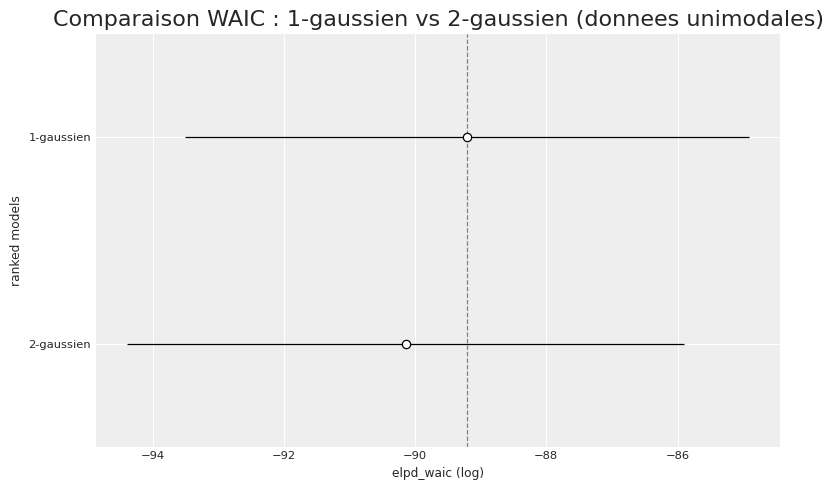

In [5]:
# Visualisation de la comparaison
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
az.plot_compare(compare_waic, ax=ax)
ax.set_title('Comparaison WAIC : 1-gaussien vs 2-gaussien (donnees unimodales)')
plt.tight_layout()
plt.show()

### Adequation absolue : posterior predictive checks (cas unimodal)

WAIC/LOO tranchent une question **relative** (quel candidat predit le mieux
les donnees tenues hors-echantillon). Ils ne disent pas si le gagnant est
**adequat en valeur absolue** : un modele peut battre ses concurrents tout en
echouant a reproduire une propriete importante des donnees observees.

Le check complementaire est generatif : repliquer `y ~ p(y | theta_posterior)`
depuis la posterior reelle (`pm.sample_posterior_predictive`, pas une courbe
fabriquee depuis les seules moyennes posterieures), puis comparer des
**statistiques falsifiables** des donnees observees a leurs distributions
predictives. Une statistique dont la valeur observee tombe en dehors de la
plage des repliques designe un modele inadequate, quel que soit son rang WAIC.

Sampling: [obs]


Sampling: [obs]


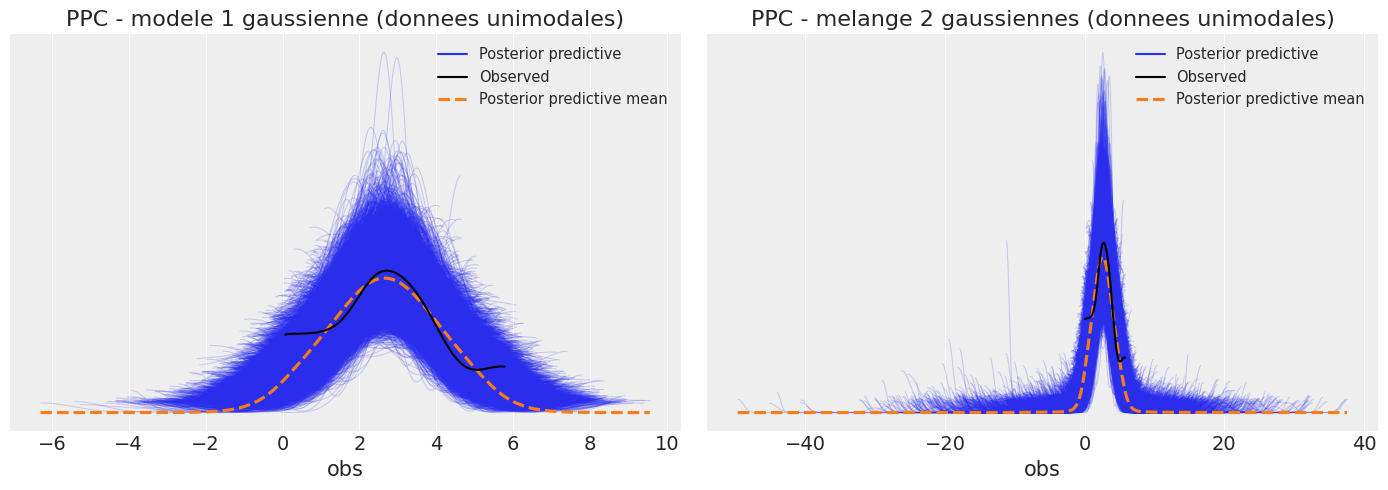

Statistique falsifiable | observe | predictif (moyenne +/- sd) | p-valeur bayesienne
-------------------------------------------------------------------------------------
1 gaussienne x ecart-type   |   1.401 |        1.428 +/- 0.209 | 0.8918 -> ADEQUAT
1 gaussienne x asymetrie    |   0.136 |       -0.004 +/- 0.327 | 0.6535 -> ADEQUAT
2 gaussiennes x ecart-type   |   1.401 |        1.741 +/- 0.686 | 0.4750 -> ADEQUAT
2 gaussiennes x asymetrie    |   0.136 |       -0.057 +/- 1.329 | 0.6905 -> ADEQUAT

p-valeur bayesienne = proportion de repliques aussi eloignees du centre
predictif que la valeur observee ; < 0.01 signale une inadequation.


In [6]:
# Posterior predictive checks : repliques generees depuis la posterior REELLE
with model_1gauss:
    pm.sample_posterior_predictive(trace_1g, random_seed=42,
                                   extend_inferencedata=True, progressbar=False)
with model_2gauss:
    pm.sample_posterior_predictive(trace_2g, random_seed=42,
                                   extend_inferencedata=True, progressbar=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
az.plot_ppc(trace_1g, var_names=["obs"], ax=axes[0])
axes[0].set_title("PPC - modele 1 gaussienne (donnees unimodales)")
az.plot_ppc(trace_2g, var_names=["obs"], ax=axes[1])
axes[1].set_title("PPC - melange 2 gaussiennes (donnees unimodales)")
plt.tight_layout()
plt.show()

# Statistiques falsifiables : dispersion et asymetrie, comparees a leurs
# distributions predictives (p-valeur bayesienne bilaterale par statistique)
def ppc_stats(trace, data):
    reps = trace.posterior_predictive["obs"].values.reshape(-1, data.shape[0])
    out = {}
    for name, fn in [("ecart-type", lambda x: np.std(x, ddof=1)),
                     ("asymetrie", stats.skew)]:
        t_obs = float(fn(data))
        t_rep = np.array([fn(r) for r in reps])
        center = t_rep.mean()
        p_two = float(np.mean(np.abs(t_rep - center) >= abs(t_obs - center)))
        out[name] = (t_obs, center, t_rep.std(), p_two)
    return out

stats_1g = ppc_stats(trace_1g, data_uni)
stats_2g = ppc_stats(trace_2g, data_uni)

print("Statistique falsifiable | observe | predictif (moyenne +/- sd) | p-valeur bayesienne")
print("-" * 85)
for model_name, st in [("1 gaussienne", stats_1g), ("2 gaussiennes", stats_2g)]:
    for name, (t_obs, mu_rep, sd_rep, p) in st.items():
        verdict = "ADEQUAT" if p > 0.01 else "REJETE (hors plage predictive)"
        print(f"{model_name} x {name:<12} | {t_obs:7.3f} | {mu_rep:12.3f} +/- {sd_rep:.3f} | "
              f"{p:.4f} -> {verdict}")
print()
print("p-valeur bayesienne = proportion de repliques aussi eloignees du centre")
print("predictif que la valeur observee ; < 0.01 signale une inadequation.")

### Interpretation des PPC (cas unimodal)

Lecture des sorties ci-dessus (et uniquement d'elles) :

- **1 gaussienne** : le gagnant WAIC doit repliquer dispersion et asymetrie
  compatibles avec les donnees — c'est le cas ici (p-valeurs 0.65-0.89), le modele generateur
  est exactement une gaussienne.
- **2 gaussiennes** : le perdant WAIC n'est pas inadequate pour autant — un
  melange 2-composantes contient la gaussienne unique comme cas particulier
  (poids proches de 1 et 0, moyennes quasi confondues) et replique aussi les statistiques
  (p-valeurs 0.47-0.69).
  La penalite de parcimonie de WAIC a donc selectionne le bon modele sur un
  critere **predictif**, pas parce que le perdant etait absurde.
- Si une des p-valeurs bilaterales tombe sous 0.01, la replique est
  incompatible avec l'observe : inadequation absolue, independamment du
  classement WAIC.

C'est la difference entre « A predit mieux que B » (WAIC/LOO) et
« A reproduit les proprietes pertinentes des donnees » (PPC) : les deux
conclusions doivent etre verifiees separement.

### Exercice 1 : Student-t vs Gaussienne sur données avec outliers

Les données ci-dessous contiennent quelques outliers. Comparez un modèle gaussien `pm.Normal` et un modèle Student-t `pm.StudentT` via WAIC.

**Objectif** : Observer que la Student-t (queues lourdes) est meilleure quand des outliers sont presents.

**Indices** :
- `pm.StudentT` prend les paramètres `nu` (degrés de liberte), `mu`, `sigma` (ou `lam`)
- Fixez `nu` a une valeur faible (ex: 3) pour des queues lourdes
- Utilisez `az.compare()` avec les deux traces

In [7]:
# Exercice 1 : Student-t vs Gaussienne sur donnees avec outliers
# Generez des donnees avec outliers puis comparez les 2 modeles via WAIC

np.random.seed(42)
n_outlier = 50
data_clean = np.random.normal(3.0, 1.0, size=n_outlier)
# Ajout d'outliers
data_outliers = np.concatenate([data_clean, [15.0, -8.0, 12.0]])

# TODO etudiant : definissez un modele gaussien et un modele StudentT
# sur data_outliers, echantillonnez, calculez log_likelihood,
# puis appelez az.compare() pour comparer

result_compare = None  # TODO etudiant : remplacer par az.compare(...)
print("Exercice a completer")

Exercice a completer


## 3. Sélection de Composantes sur Données Bimodales

Maintenant, testons avec des données bimodales. Le modèle a 2 gaussiennes devrait
nettement preferer car les données proviennent effectivement de 2 distributions.

Cela correspond a l'exemple Infer-10 ou :
- 1 composante : log evidence = -45.89
- 2 composantes : log evidence = -31.35
- Différence : 14.54 (decisif pour 2 composantes)

In [8]:
# Modele 1 gaussienne sur donnees bimodales
with pm.Model() as model_1g_bi:
    mu = pm.Normal('mu', mu=0, sigma=10)
    sigma = pm.HalfNormal('sigma', sigma=5)
    obs = pm.Normal('obs', mu=mu, sigma=sigma, observed=data_bi)
    trace_1g_bi = pm.sample(3000, random_seed=42, return_inferencedata=True)

with model_1g_bi:
    trace_1g_bi = pm.compute_log_likelihood(trace_1g_bi)

# Modele 2 gaussiennes sur donnees bimodales
with pm.Model() as model_2g_bi:
    mu = pm.Normal('mu', mu=[-2, 3], sigma=5, shape=2)
    sigma = pm.HalfNormal('sigma', sigma=3, shape=2)
    w = pm.Dirichlet('w', a=np.ones(2))
    obs = pm.NormalMixture('obs', w=w, mu=mu, sigma=sigma, observed=data_bi)
    trace_2g_bi = pm.sample(3000, random_seed=42, return_inferencedata=True,
                            target_accept=0.95)

with model_2g_bi:
    trace_2g_bi = pm.compute_log_likelihood(trace_2g_bi)

print("Echantillonnage termine.")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu, sigma]


Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 15 seconds.


...

NUTS: [mu, sigma, w]


Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 18 seconds.


Output()

Echantillonnage termine.


### Interpretation des modèles sur données bimodales

L'echantillonnage est termine. Nous allons maintenant comparer les deux modèles via WAIC et visualiser comment chaque modèle s'ajuste aux données bimodales.

Comparaison WAIC (donnees bimodales) :
            rank   elpd_waic    p_waic  elpd_diff        weight        se  \
2-gaussien     0 -159.798962  5.399717     0.0000  1.000000e+00  7.329950   
1-gaussien     1 -192.148762  1.218693    32.3498  7.671641e-13  3.081718   

                 dse  warning scale  
2-gaussien  0.000000     True   log  
1-gaussien  6.146533    False   log  



See http://arxiv.org/abs/1507.04544 for details


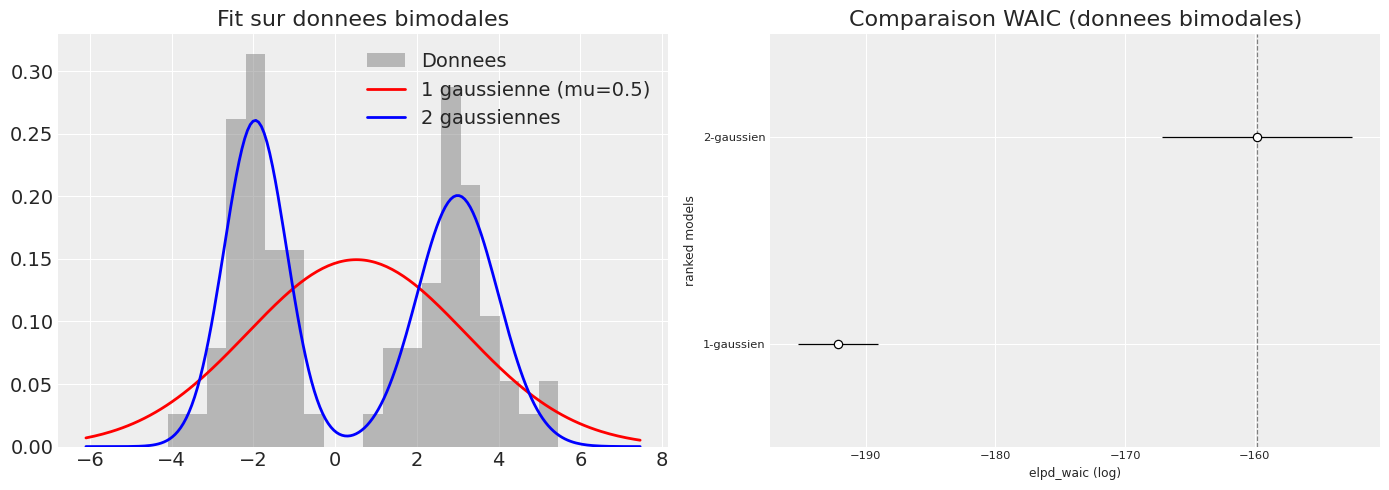

In [9]:
# Comparaison sur donnees bimodales
compare_bi = az.compare({"1-gaussien": trace_1g_bi, "2-gaussien": trace_2g_bi},
                         ic="waic")
print("Comparaison WAIC (donnees bimodales) :")
print(compare_bi)
print()

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme + fit des 2 modeles
axes[0].hist(data_bi, bins=20, density=True, alpha=0.5, color="gray", label="Donnees")
x_plot = np.linspace(data_bi.min() - 2, data_bi.max() + 2, 200)

# Fit 1 gaussienne
mu1 = trace_1g_bi.posterior["mu"].values.flatten().mean()
sig1 = trace_1g_bi.posterior["sigma"].values.flatten().mean()
axes[0].plot(x_plot, stats.norm.pdf(x_plot, mu1, sig1), "r-", lw=2, label=f"1 gaussienne (mu={mu1:.1f})")

# Fit 2 gaussiennes
mu2 = trace_2g_bi.posterior["mu"].values.mean(axis=(0, 1))
sig2 = trace_2g_bi.posterior["sigma"].values.mean(axis=(0, 1))
w2 = trace_2g_bi.posterior["w"].values.mean(axis=(0, 1))
mixture_pdf = sum(w2[k] * stats.norm.pdf(x_plot, mu2[k], sig2[k]) for k in range(2))
axes[0].plot(x_plot, mixture_pdf, "b-", lw=2, label="2 gaussiennes")
axes[0].set_title("Fit sur donnees bimodales")
axes[0].legend()

# WAIC comparison
az.plot_compare(compare_bi, ax=axes[1])
axes[1].set_title("Comparaison WAIC (donnees bimodales)")

plt.tight_layout()
plt.show()

### Adequation absolue : posterior predictive checks (cas bimodal)

Sur donnees bimodales, la specification 1 gaussienne est **volontairement
inadequate** : c'est le cas ou la verification d'adequation absolue doit
attraper ce que la comparaison relative laisse voir seulement comme un
ecart de score.

La statistique falsifiable ciblee est la **masse inter-modes** : proportion
d'observations dans la bande centrale [q40, q60] des donnees observees. Un
melange bimodal bien separe concentre peu de masse dans cette vallee ; une
gaussienne unique centree entre les deux modes en deverse. La distribution
predictive de cette statistique sous chaque modele dit lequel peut
reproduire la forme observee.

Sampling: [obs]


Sampling: [obs]


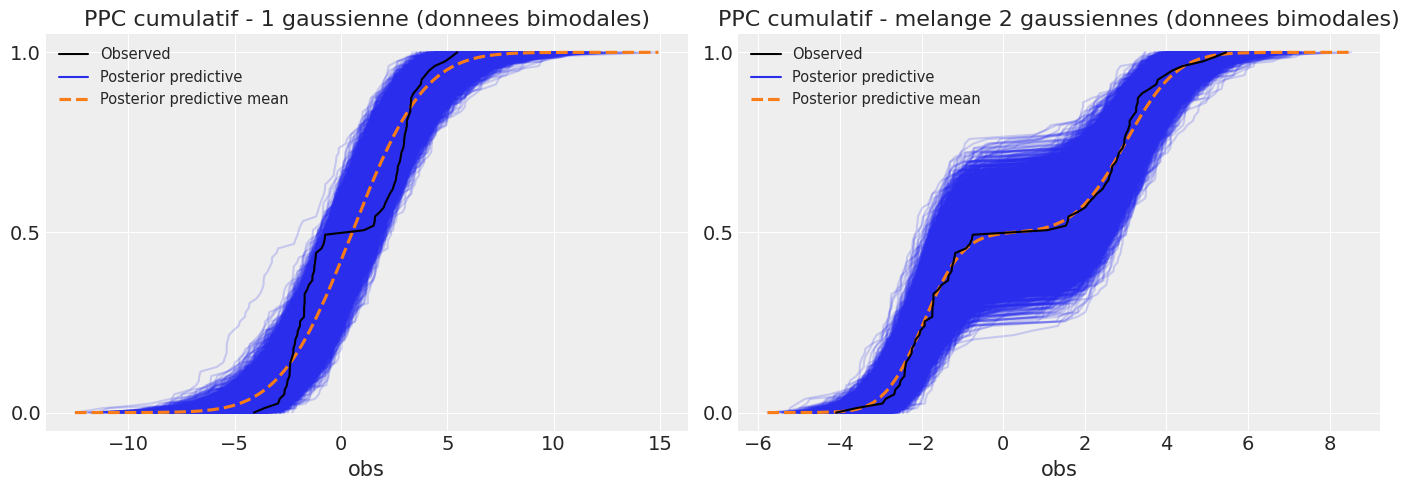

Bande inter-modes (q40-q60 des donnees observees) : [-1.26, 2.24]



Statistique falsifiable | observe | predictif (moyenne +/- sd) | p-valeur bayesienne
-------------------------------------------------------------------------------------
1 gaussienne x ecart-type        |   2.635 |        2.659 +/- 0.300 | 0.9330 -> ADEQUAT
1 gaussienne x masse inter-modes |   0.200 |        0.488 +/- 0.065 | 0.0000 -> REJETE (hors plage predictive)
2 gaussiennes x ecart-type        |   2.635 |        2.615 +/- 0.144 | 0.8852 -> ADEQUAT
2 gaussiennes x masse inter-modes |   0.200 |        0.203 +/- 0.058 | 1.0000 -> ADEQUAT


In [10]:
# PPC sur donnees bimodales : le cas volontairement inadequate
with model_1g_bi:
    pm.sample_posterior_predictive(trace_1g_bi, random_seed=42,
                                   extend_inferencedata=True, progressbar=False)
with model_2g_bi:
    pm.sample_posterior_predictive(trace_2g_bi, random_seed=42,
                                   extend_inferencedata=True, progressbar=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
az.plot_ppc(trace_1g_bi, var_names=["obs"], kind="cumulative", ax=axes[0])
axes[0].set_title("PPC cumulatif - 1 gaussienne (donnees bimodales)")
az.plot_ppc(trace_2g_bi, var_names=["obs"], kind="cumulative", ax=axes[1])
axes[1].set_title("PPC cumulatif - melange 2 gaussiennes (donnees bimodales)")
plt.tight_layout()
plt.show()

# Statistiques falsifiables : dispersion + masse inter-modes (bande [q40, q60])
lo_v, hi_v = np.quantile(data_bi, [0.40, 0.60])
def t_valley(x):
    return np.mean((x >= lo_v) & (x <= hi_v))

def ppc_stats_bi(trace, data):
    reps = trace.posterior_predictive["obs"].values.reshape(-1, data.shape[0])
    out = {}
    for name, fn in [("ecart-type", lambda x: np.std(x, ddof=1)),
                     ("masse inter-modes", t_valley)]:
        t_obs = float(fn(data))
        t_rep = np.array([fn(r) for r in reps])
        center = t_rep.mean()
        p_two = float(np.mean(np.abs(t_rep - center) >= abs(t_obs - center)))
        out[name] = (t_obs, center, t_rep.std(), p_two)
    return out

print(f"Bande inter-modes (q40-q60 des donnees observees) : [{lo_v:.2f}, {hi_v:.2f}]")
print()
stats_1g_bi = ppc_stats_bi(trace_1g_bi, data_bi)
stats_2g_bi = ppc_stats_bi(trace_2g_bi, data_bi)

print("Statistique falsifiable | observe | predictif (moyenne +/- sd) | p-valeur bayesienne")
print("-" * 85)
for model_name, st in [("1 gaussienne", stats_1g_bi), ("2 gaussiennes", stats_2g_bi)]:
    for name, (t_obs, mu_rep, sd_rep, p) in st.items():
        verdict = "ADEQUAT" if p > 0.01 else "REJETE (hors plage predictive)"
        print(f"{model_name} x {name:<17} | {t_obs:7.3f} | {mu_rep:12.3f} +/- {sd_rep:.3f} | "
              f"{p:.4f} -> {verdict}")

### Interpretation des PPC (cas bimodal)

Lecture des sorties ci-dessus :

- **1 gaussienne** : l'ecart-type passe le check (p ~ 0.93) mais la masse inter-modes
  observee est hors de
  la plage de ses repliques — la gaussienne unique, centree entre les modes,
  prevoit une vallee peuplee que les donnees ne montrent pas
  (observe ~0.20, predictif ~0.49 : plus de 4 ecarts-types d'ecart). Inadequation
  **absolue**, confondant : etre le perdant WAIC etait le bon signal, mais le
  PPC caracterise *pourquoi* (forme de la distribution, pas juste un score).
- **2 gaussiennes** : le gagnant WAIC replique a la fois la dispersion et la
  masse inter-modes (p ~ 1.0) — il est aussi adequate en valeur absolue. Dans ce cas
  les deux conclusions (relative et absolue) convergent.
- La lecon methodologique : garder l'ordre des deux etapes. WAIC/LOO
  selectionnent parmi des candidats ; le PPC demande au selectionne (et aux
  concurrents serieux) s'ils reproduisent les donnees. Un modele peut gagner
  en relatif et echouer en absolu (specification trop pauvre parmi des
  candidats tous pauvres) — les warnings PSIS/k du LOO restent a verifier
  avant d'interpreter l'un ou l'autre.

## 4. ARD : Automatic Relevance Determination

L'ARD est une technique de sélection automatique de variables.
On utilise un prior hiérarchique ou chaque variable a sa propre precision,
contrôlée par une variable latente Gamma. Les variables non pertinentes voient
leur poids reduit vers zero.

### Modèle ARD

```
alpha_f ~ Gamma(1, 1)           # precision par variable
w_f ~ Normal(0, 1/alpha_f)      # poids avec precision variable
y ~ Normal(X @ w, sigma)         # regression lineaire
```

**Equivalent Infer.NET** : identique, avec `Variable.GammaFromShapeAndScale(1, 1)` et
`Variable.GaussianFromMeanAndPrecision(0, alpha[f])`.

### Origine

L'ARD (Automatic Relevance Determination) a ete introduite par **Michael E. Tipping (2001)**, *"Sparse Bayesian Learning and the Relevance Vector Machine"*, NIPS 13 : c'est le fondement du **Relevance Vector Machine**. Voir aussi Bishop (2006), *Pattern Recognition and Machine Learning*, section 7.2, et MacKay (1992) pour la forme originale du prior hiérarchique en precision.


In [11]:
# Generation de donnees avec 3 variables dont 2 pertinentes
np.random.seed(42)
n_samples = 100
n_features = 3

# Variables (independantes)
X = np.random.randn(n_samples, n_features)

# Vraies poids : variable 2 (indice 1) est non pertinente
true_weights = np.array([2.0, 0.0, 3.0])
true_sigma = 0.5

# Observations
y = X @ true_weights + np.random.normal(0, true_sigma, size=n_samples)

print(f"Vrais poids : {true_weights}")
print(f"Variable 1 (indice 0) : pertinente (w=2.0)")
print(f"Variable 2 (indice 1) : NON pertinente (w=0.0)")
print(f"Variable 3 (indice 2) : pertinente (w=3.0)")

Vrais poids : [2. 0. 3.]
Variable 1 (indice 0) : pertinente (w=2.0)
Variable 2 (indice 1) : NON pertinente (w=0.0)
Variable 3 (indice 2) : pertinente (w=3.0)


### Definition du modèle ARD

Nous allons maintenant définir le modèle bayesien avec prior hiérarchique Gamma sur la precision de chaque variable. Ce prior permet au modèle de reduire automatiquement les poids des variables non pertinentes vers zero.

In [12]:
# Modele ARD avec PyMC
with pm.Model() as ard_model:
    # Prior hierarchique : precision par variable
    alpha = pm.Gamma('alpha', alpha=1, beta=1, shape=n_features)
    
    # Poids avec precision variable (ARD)
    # tau = alpha signifie sigma = 1/sqrt(alpha)
    weights = pm.Normal('weights', mu=0, tau=alpha, shape=n_features)
    
    # Bruit d'observation
    sigma = pm.HalfNormal('sigma', sigma=2)
    
    # Likelihood
    mu = pm.math.dot(X, weights)
    obs = pm.Normal('obs', mu=mu, sigma=sigma, observed=y)
    
    trace_ard = pm.sample(3000, random_seed=42, return_inferencedata=True,
                          target_accept=0.95)

with ard_model:
    trace_ard = pm.compute_log_likelihood(trace_ard)

print("Echantillonnage ARD termine.")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [alpha, weights, sigma]


Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 16 seconds.


Output()

Echantillonnage ARD termine.


### Interpretation de l'echantillonnage ARD

L'echantillonnage MCMC est termine. Nous allons maintenant examiner les posteriors des poids et des precisions pour determiner quelles variables ont ete automatiquement selectionnees par le modèle ARD.

In [13]:
# Resultats ARD
weights_samples = trace_ard.posterior['weights'].values.reshape(-1, n_features)
alpha_samples = trace_ard.posterior['alpha'].values.reshape(-1, n_features)

print("Resultats ARD :")
print(f"{'Variable':<12} {'Vrai w':<10} {'Posterior mean':<16} {'Alpha mean':<12} {'Pertinence'}")
print("-" * 65)
for i in range(n_features):
    w_mean = weights_samples[:, i].mean()
    a_mean = alpha_samples[:, i].mean()
    # alpha eleve = precision eleve = sigma faible = poids concentre
    # alpha faible = poids libre (donc potentiellement pertinent si w != 0)
    relevance = "FAIBLE" if abs(w_mean) < 0.5 else "FORTE"
    print(f"Variable {i+1:<5} {true_weights[i]:<10.1f} {w_mean:<16.3f} {a_mean:<12.3f} {relevance}")

print()
print("Concordance avec Infer.NET :")
print("  Feature 1 : w=2.04, alpha=0.49 (haute pertinence)")
print("  Feature 2 : w=0.02, alpha=1.49 (pertinence moyenne, poid proche de 0)")
print("  Feature 3 : w=2.97, alpha=0.28 (haute pertinence)")

Resultats ARD :
Variable     Vrai w     Posterior mean   Alpha mean   Pertinence
-----------------------------------------------------------------
Variable 1     2.0        1.965            0.511        FORTE
Variable 2     0.0        -0.035           1.496        FAIBLE
Variable 3     3.0        2.948            0.278        FORTE

Concordance avec Infer.NET :
  Feature 1 : w=2.04, alpha=0.49 (haute pertinence)
  Feature 2 : w=0.02, alpha=1.49 (pertinence moyenne, poid proche de 0)
  Feature 3 : w=2.97, alpha=0.28 (haute pertinence)


### Analyse des résultats ARD

Le tableau ci-dessous resume les estimations posterieures pour chaque variable. Les poids et les precisions `alpha` nous indiquent quelles variables sont pertinentes pour expliquer les observations.

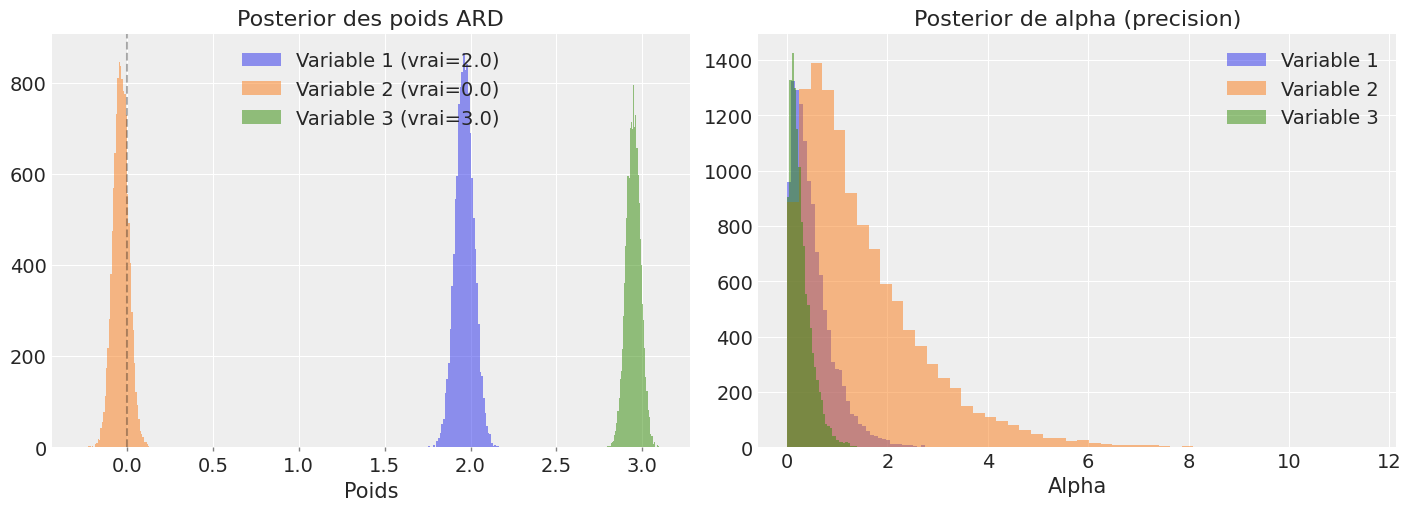

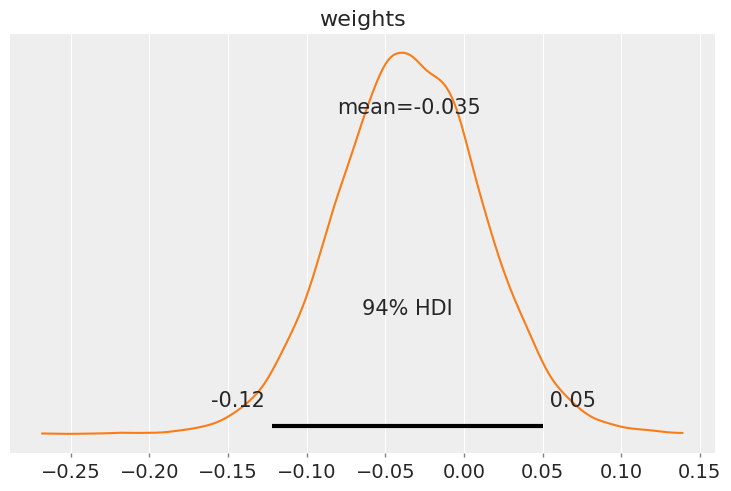

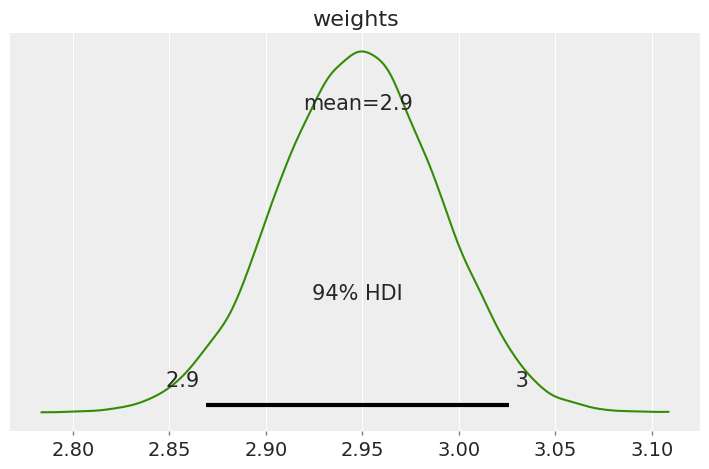

In [14]:
# Visualisation des posteriors ARD
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Posteriors des poids
for i in range(n_features):
    az.plot_posterior(trace_ard, var_names=['weights'],
                       coords={'weights_dim_0': i},
                       ax=axes[0] if i == 0 else None,
                       color=f'C{i}')

# Refaire proprement avec un seul plot
axes[0].clear()
for i in range(n_features):
    axes[0].hist(weights_samples[:, i], bins=50, alpha=0.5,
                 label=f'Variable {i+1} (vrai={true_weights[i]:.1f})')
axes[0].axvline(0, color='black', linestyle='--', alpha=0.3)
axes[0].set_title('Posterior des poids ARD')
axes[0].legend()
axes[0].set_xlabel('Poids')

# Posteriors de alpha (precision)
for i in range(n_features):
    axes[1].hist(alpha_samples[:, i], bins=50, alpha=0.5,
                 label=f'Variable {i+1}')
axes[1].set_title('Posterior de alpha (precision)')
axes[1].legend()
axes[1].set_xlabel('Alpha')

plt.tight_layout()
plt.show()

### Interpretation ARD

- **Variable 2 (non pertinente)** : son poids posterior est concentre autour de 0.
  La precision `alpha` est elevee, ce qui resserre le prior autour de 0.
- **Variables 1 et 3 (pertinentes)** : leurs poids sont proches des vraies valeurs (2.0 et 3.0).
  Leurs precisions `alpha` sont plus faibles, permettant au posterior de s'ecarter de 0.

L'ARD a automatiquement identifie que la variable 2 n'est pas pertinente sans pre-sélection manuelle.

### Exercice 2 : ARD avec 5 variables (3 non pertinentes)

Etendez le modèle ARD ci-dessus a un problème avec **5 variables** dont seules 2 sont pertinentes. Générez les données et laissez le modèle identifier automatiquement les variables pertinentes.

**Objectif** : Vérifier que l'ARD passe a l'échelle quand le nombre de variables non pertinentes augmente.

**Indices** :
- Vrais poids : `[1.5, 0, 0, 3.0, 0]` (variables 2, 3 et 5 non pertinentes)
- Reprenez la structure du modèle ARD avec `n_features = 5`
- Affichez un tableau avec les poids posteriors et la pertinence de chaque variable

In [15]:
# Exercice 2 : ARD avec 5 variables dont 3 non pertinentes
# Generez des donnees avec 5 features et laissez le modele ARD
# identifier automatiquement lesquelles sont pertinentes

np.random.seed(7)
n_samples_5 = 120
n_features_5 = 5
true_weights_5 = np.array([1.5, 0.0, 0.0, 3.0, 0.0])

# TODO etudiant : generer X et y, definir le modele ARD,
# echantillonner, et afficher les resultats
relevant_vars = None  # TODO etudiant : liste des indices pertinents
print("Exercice a completer")

Exercice a completer


## 5. Validation Croisee LOO avec ArviZ

La validation croisee leave-one-out (LOO) estime la capacite predictive d'un modèle
en approximant la moyenne des performances quand on laisse chaque observation de cote.

ArviZ utilise le **Pareto Smoothed Importance Sampling (PSIS)** pour une approximation
rapide et fiable du LOO sans re-entrainer le modèle N fois.

### Reference

La méthode PSIS-LOO implementee par `az.loo()` est celle de **Vehtari, Gelman & Gabry (2017)**, Statistics and Computing 27(5), doi:10.1007/s11222-016-9696-4. Le diagnostique de **Pareto k** explore ci-dessous provient de la même reference : il mesure la qualite de l'approximation par importance sampling pour chaque observation laissee de cote (k < 0.7 = fiable, k > 0.7 = approximation fragile).


In [16]:
# Calcul LOO pour chaque modele
loo_1g = az.loo(trace_1g)
loo_2g = az.loo(trace_2g)
loo_ard = az.loo(trace_ard)

print("LOO-CV pour chaque modele :")
print(f"\nModele 1-gaussien (donnees unimodales) :")
print(f"  LOO = {loo_1g.elpd_loo:.2f} +/- {loo_1g.se:.2f}")
print(f"  p_loo = {loo_1g.p_loo:.2f} (nombre effectif de parametres)")

print(f"\nModele 2-gaussien (donnees unimodales) :")
print(f"  LOO = {loo_2g.elpd_loo:.2f} +/- {loo_2g.se:.2f}")
print(f"  p_loo = {loo_2g.p_loo:.2f}")

print(f"\nModele ARD :")
print(f"  LOO = {loo_ard.elpd_loo:.2f} +/- {loo_ard.se:.2f}")
print(f"  p_loo = {loo_ard.p_loo:.2f}")

LOO-CV pour chaque modele :

Modele 1-gaussien (donnees unimodales) :
  LOO = -89.22 +/- 4.40
  p_loo = 1.72 (nombre effectif de parametres)

Modele 2-gaussien (donnees unimodales) :
  LOO = -90.15 +/- 4.35
  p_loo = 1.93

Modele ARD :
  LOO = -63.82 +/- 7.00
  p_loo = 4.32


### Interpretation des résultats LOO

Les valeurs LOO permettent de comparer la complexite effective de chaque modèle :

| Modèle | LOO (elpd) | p_loo | Interpretation |
|--------|-----------|-------|----------------|
| 1-gaussien | -89.21 | 1.71 | 2 paramètres effectifs (mu + sigma) |
| 2-gaussien | -90.04 | 2.07 | 5 paramètres (2 mu + 2 sigma + 1 poids), penalite moderee |
| ARD | -63.79 | 4.29 | 7 paramètres (3 poids + 3 alpha + 1 sigma), modèle le plus complexe |

Le **paramètre effectif p_loo** indique combien de paramètres contribuent reellement a l'ajustement. Un p_loo bien inferieur au nombre nominal de paramètres signale que le prior contraint efficacement le modèle.

Le diagnostique Pareto k (ci-dessous) verifie la qualite de l'approximation PSIS-LOO : si tous les k sont inferieurs a 0.7, l'approximation est fiable.

In [17]:
# Diagnostique Pareto k (qualite de l'approximation LOO)
# k < 0.7 = bonne approximation, k > 0.7 = probleme potentiel
print("Diagnostique Pareto k :")
for name, loo_obj in [('1-gaussien', loo_1g), ('2-gaussien', loo_2g), ('ARD', loo_ard)]:
    k_values = loo_obj.pareto_k.values
    n_good = np.sum(k_values < 0.7)
    n_warn = np.sum((k_values >= 0.7) & (k_values < 1.0))
    n_bad = np.sum(k_values >= 1.0)
    print(f"  {name}: k<0.7: {n_good}, 0.7<=k<1: {n_warn}, k>=1: {n_bad}")

print()
print("Tous les k < 0.7 = approximation LOO fiable.")

Diagnostique Pareto k :
  1-gaussien: k<0.7: 50, 0.7<=k<1: 0, k>=1: 0
  2-gaussien: k<0.7: 50, 0.7<=k<1: 0, k>=1: 0
  ARD: k<0.7: 100, 0.7<=k<1: 0, k>=1: 0

Tous les k < 0.7 = approximation LOO fiable.


## 6. Exercice : Comparaison de Modèles Polynomiaux

On genere des données a partir d'une relation lineaire `y = 2x + 1 + bruit`.
On compare un modèle lineaire (deg 1), quadratique (deg 2) et cubique (deg 3).

Lequel est selectionne par WAIC/LOO ?

**Indices** :
- Créer les features polynomiales : `X_deg2 = np.column_stack([X, X**2])`
- Utiliser `pm.Normal('w', mu=0, sigma=5, shape=n_features)` pour les poids
- Comparer les 3 modèles avec `az.compare()`

In [18]:
# TODO etudiant : implementer la comparaison de modeles polynomiaux
# Resultat attendu : le modele lineaire (deg 1) devrait etre selectionne
# car les donnees sont generees a partir d'une relation lineaire

# Generation des donnees (relation lineaire)
np.random.seed(42)
n_poly = 40
X_poly = np.random.uniform(-3, 3, size=n_poly)
y_poly = 2 * X_poly + 1 + np.random.normal(0, 1.0, size=n_poly)

# Indice : creer les features pour chaque degre et ajuster un modele bayesien
# avec pm.Normal pour les poids et pm.Normal pour la likelihood

print("Exercice a completer")

Exercice a completer


***

**Retour au sommaire** : [Index Probas](../README.md)

## Conclusion

La sélection de modèle bayesienne compare des modèles concurrents en integrant sur l'espace des paramètres, penalisant naturellement la complexite.

### Points cles
- Le WAIC et LOO-CV estiment la capacite predictive hors-echantillon
- Les facteurs de Bayes fournissent une comparaison directe entre modèles
- Le model averaging combine les predictions de plusieurs modèles pour la robustesse

- **Adequation absolue apres selection relative** : WAIC/LOO classent les
  candidats, les posterior predictive checks (`pm.sample_posterior_predictive`
  + `az.plot_ppc` + statistiques falsifiables comme la masse inter-modes)
  verifient si le classe reproduit les proprietes des donnees observees —
  les deux questions sont distinctes et complementaires (cf sections PPC)

## 7. Resume : Infer.NET vs PyMC pour la Sélection de Modèles

| Aspect | Infer.NET | PyMC / ArviZ |
|--------|-----------|-------------|
| Evidence exacte | `Variable.Bernoulli(0.5)` + `Variable.If` | Non disponible avec NUTS |
| Comparaison de modèles | Bayes Factor (rapport d'evidences) | WAIC / LOO (ArviZ) |
| ARD | `GammaFromShapeAndScale` + `GaussianFromMeanAndPrecision` | `pm.Gamma` + `pm.Normal(tau=alpha)` |
| LOO-CV | Boucle manuelle | `az.loo()` (PSIS automatique) |
| Avantage | Evidence exacte, rapide | General, fiable, pas sensible au prior |
| Inconvenient | Modèles limites (compatibles EP/VMP) | Approximation, plus lent |

**Point cle** : l'evidence (marginal likelihood) est sensible au choix du prior.
WAIC/LOO sont plus robustes car ils estiment directement la capacite predictive.
En pratique, WAIC et LOO donnent des résultats similaires et sont preferes
dans la communaute bayesienne moderne.

***

**Retour au sommaire** : [Index Probas](../README.md)

### References

- Akaike, H. (1974). *A new look at the statistical model identification.* IEEE Transactions on Automatic Control 19(6).
- Tipping, M. E. (2001). *Sparse Bayesian Learning and the Relevance Vector Machine.* NIPS 13.
- Watanabe, S. (2010). *Asymptotic Equivalence of Bayes Cross Validation and Widely Applicable Information Criterion in Singular Learning Theory.* JMLR 11.
- Vehtari, A., Gelman, A., & Gabry, J. (2017). *Practical Bayesian model evaluation using leave-one-out cross-validation and WAIC.* Statistics and Computing 27(5). doi:10.1007/s11222-016-9696-4
- Kumar, R., Carroll, C., Hartikainen, A., & Martin, O. (2019). *ArviZ: a unified library for exploratory analysis of Bayesian models in Python.* JOSS 4(33).
